# Monoculture Logistic Growth Fit
This notebook performs a clean logistic growth fit on the two untreated monoculture datasets.

What you get:
- Data loading and preprocessing (day extraction and averaging)
- Logistic ODE fit with parameter bounds
- Sum of Squared Residuals (SSR) and Bayesian Information Criterion (BIC)
- Plot of data with fitted model curve and a concise parameter report

> Notes:
- Uses CSV, DataFrames, DifferentialEquations, Optimization, and BlackBoxOptim.
- If packages are missing, add them in your Julia REPL: Pkg.add("CSV"), etc.

In [1]:
# 1) Packages
using Pkg
pkgs = [
    "CSV", "DataFrames", "Statistics",
    "DifferentialEquations", "DiffEqParamEstim",
    "Optimization", "OptimizationOptimJL",
    "BlackBoxOptim", "Plots", "Glob"
 ]
for p in pkgs
    try
        Base.eval(Main, :(import $(Symbol(p))))
    catch
        Pkg.add(p)
        Base.eval(Main, :(import $(Symbol(p))))
    end
end
println("✔ Packages ready: ", join(pkgs, ", "))

    Updating registry at `C:\Users\elbak\.julia\registries\General.toml`
   Resolving package versions...
   Resolving package versions...
   Installed Glob ─ v1.3.1
   Installed Glob ─ v1.3.1
    Updating `C:\Users\elbak\.julia\environments\v1.11\Project.toml`
    Updating `C:\Users\elbak\.julia\environments\v1.11\Project.toml`
  [c27321d9] + Glob v1.3.1
    Updating `C:\Users\elbak\.julia\environments\v1.11\Manifest.toml`
  [c27321d9] + Glob v1.3.1
    Updating `C:\Users\elbak\.julia\environments\v1.11\Manifest.toml`
  [c27321d9] + Glob v1.3.1
  [c27321d9] + Glob v1.3.1
PrecompilingPrecompiling  project...project...

  10422.5 ms  10422.5 ms  ✓   ✓ Glob
Glob
  1 dependency successfully precompiled in 39 seconds. 588 already precompiled.
  1 dependency successfully precompiled in 39 seconds. 588 already precompiled.


✔ Packages ready: CSV, DataFrames, Statistics, DifferentialEquations, DiffEqParamEstim, Optimization, OptimizationOptimJL, BlackBoxOptim, Plots, Glob


In [2]:
# Ensure Distributions is available for Uniform and related types
using Pkg
Pkg.add("Distributions")
using Distributions

   Resolving package versions...
    Updating    Updating `C:\Users\elbak\.julia\environments\v1.11\Project.toml`
  [31c24e10] + Distributions v0.25.120
  No Changes to `C:\Users\elbak\.julia\environments\v1.11\Manifest.toml`
 `C:\Users\elbak\.julia\environments\v1.11\Project.toml`
  [31c24e10] + Distributions v0.25.120
  No Changes to `C:\Users\elbak\.julia\environments\v1.11\Manifest.toml`


In [3]:
# 2) Using imports
using CSV, DataFrames, Statistics
using DifferentialEquations
using DiffEqParamEstim
using Optimization, OptimizationOptimJL
using BlackBoxOptim
using Plots
using Printf
using Glob

In [15]:
# 3) Models
function logistic!(du, u, p, t)
    r, K = p
    du[1] = r * u[1] * (1 - u[1]/K)
end

logistic! (generic function with 1 method)

In [16]:
# 4) Main functions (fast path; CSVs already contain day averages)
struct FitResult
    r::Float64
    K::Float64
    SSR::Float64
    BIC::Float64
end

# Helper: find a column by fuzzy name (case-insensitive substring match)
function _find_col(df::DataFrame; must_include::Vector{String}=[])
    for c in names(df)
        s = lowercase(String(c))
        ok = all(substr -> occursin(substr, s), must_include)
        ok && return Symbol(c)
    end
    return nothing
end

# Collapse duplicate x values by mean of y
function dedupe_xy(x::Vector{Float64}, y::Vector{Float64})
    df = DataFrame(day=x, value=y)
    g = combine(groupby(df, :day), :value => mean => :value)
    return Float64.(g.day), Float64.(g.value)
end

# Read pre-averaged data: prefer Cells-based headers (backward-compatible)
function load_monoculture_csv(path::AbstractString; scale_if_area::Float64=1.0)
    df = CSV.read(path, DataFrame)
    # Detect the day column
    daycol = nothing
    if :day ∈ names(df)
        daycol = :day
    elseif :Day ∈ names(df)
        daycol = :Day
    else
        # any column whose name contains "day"
        daycol = _find_col(df; must_include=["day"])
    end
    daycol === nothing && error("Could not find a 'day' column in $(basename(path))")

    # Detect value column (prefer Cells)
    preferred_exact = (
        :Cells, Symbol("Mean Cells"), Symbol("Average_Cells"), Symbol("Mean_Cells")
    )
    valcol = nothing
    for cand in preferred_exact
        if cand ∈ names(df)
            valcol = cand
            break
        end
    end
    if valcol === nothing
        # fuzzy search prioritizing 'cells'
        valcol = _find_col(df; must_include=["cells"])  # e.g., "mean cells"
    end
    if valcol === nothing
        # legacy: mean area columns or raw area
        valcol = _find_col(df; must_include=["mean","area"])  # e.g., "Mean Area µm^2"
        if valcol === nothing && Symbol("Area µm^2") ∈ names(df)
            valcol = Symbol("Area µm^2")
        end
    end
    valcol === nothing && error("No suitable value column found in $(basename(path)). Looked for Cells/Mean Cells/Area.")

    x = Float64.(df[!, daycol])
    y = Float64.(df[!, valcol])

    # Only scale if it's clearly an area column
    valname = lowercase(String(valcol))
    if occursin("area", valname) && scale_if_area != 1.0
        y ./= scale_if_area
    end

    # Sort and dedupe identical days by averaging y
    perm = sortperm(x)
    x = x[perm]; y = y[perm]
    return dedupe_xy(x, y)
end

# Specialized loader for day-average CSVs: returns (x, y, yerr)
function load_day_averages(path::AbstractString)
    df = CSV.read(path, DataFrame)
    # day column
    daycol = if :Day ∈ names(df)
        :Day
    else
        _find_col(df; must_include=["day"]) |> x -> x === nothing ? error("No Day column in $(basename(path))") : x
    end
    # mean value column (Cells)
    valcol = if Symbol("Mean Cells") ∈ names(df)
        Symbol("Mean Cells")
    elseif Symbol("Mean_Cells") ∈ names(df)
        Symbol("Mean_Cells")
    else
        _find_col(df; must_include=["mean","cells"]) |> x -> x === nothing ? error("No mean cells column in $(basename(path))") : x
    end
    # error column: prefer SEM, fallback to SD
    errcol = if Symbol("SEM Cells") ∈ names(df)
        Symbol("SEM Cells")
    elseif Symbol("Std_Error_Cells") ∈ names(df)
        Symbol("Std_Error_Cells")
    elseif Symbol("SD Cells") ∈ names(df)
        Symbol("SD Cells")
    elseif Symbol("Std_Dev_Cells") ∈ names(df)
        Symbol("Std_Dev_Cells")
    else
        nothing
    end
    x = Float64.(df[!, daycol])
    y = Float64.(df[!, valcol])
    yerr = isnothing(errcol) ? nothing : Float64.(df[!, errcol])
    # sort by day
    perm = sortperm(x)
    x = x[perm]; y = y[perm]; yerr = isnothing(yerr) ? nothing : yerr[perm]
    return x, y, yerr
end

# Helper to infer seeding density (e.g., "20k" or "30k") from a file path
function infer_density(path::AbstractString)
    for part in reverse(splitpath(String(path)))
        lp = lowercase(part)
        if lp == "20k" || lp == "30k"
            return part
        end
    end
    return ""
end

# Fit logistic and compute SSR + BIC (adaptive bounds)
function fit_logistic(x::Vector{<:Real}, y::Vector{<:Real}; r_bounds::Tuple{Float64,Float64}=(0.0, 2.0), K_bounds::Union{Nothing,Tuple{Float64,Float64}}=nothing)
    x = collect(Float64.(x)); y = collect(Float64.(y))
    tspan = (x[1], x[end])
    u0 = [max(y[1], eps())]
    # Adaptive K upper bound near ~2-5x max observed
    ymax = maximum(y)
    k_hi = isnothing(K_bounds) ? max(100.0, 5*ymax) : K_bounds[2]
    k_lo = isnothing(K_bounds) ? max(ymax/10, 1.0) : K_bounds[1]
    bounds = [r_bounds, (k_lo, k_hi)]
    best_p, best_sol, best_loss = nothing, nothing, Inf
    solver = Rosenbrock23()
    for _ in 1:10
        p0 = [rand(Uniform(r_bounds...)), rand(Uniform(bounds[2]...))]
        prob = ODEProblem(logistic!, u0, tspan, p0)
        obj = build_loss_objective(prob, solver, L2Loss(x, y), Optimization.AutoForwardDiff())
        res = bboptimize(obj; SearchRange=bounds, MaxTime=20.0, TraceMode=:silent)
        p̂ = best_candidate(res)
        sol̂ = solve(remake(prob, p=p̂), solver; saveat=x, reltol=1e-9, abstol=1e-9)
        pred = getindex.(sol̂.u, 1)
        if length(pred) != length(y)
            # Safety: re-solve if mismatch
            sol̂ = solve(remake(prob, p=p̂), solver; saveat=x)
            pred = getindex.(sol̂.u, 1)
        end
        loss = sum(abs2.(y .- pred))
        if loss < best_loss
            best_p, best_sol, best_loss = p̂, sol̂, loss
        end
    end
    n = length(y); k = 2
    ssr = best_loss
    bic = n > k ? n*log(ssr/n) + k*log(n) : NaN
    return best_p, best_sol, FitResult(best_p[1], best_p[2], ssr, bic)
end

function plot_data_and_fit(x, y, sol; title_str="Logistic Fit", yerr=nothing)
    if yerr === nothing
        plt = scatter(x, y; label="Data", xlabel="Day", ylabel="Cells", title=title_str)
    else
        plt = scatter(x, y; yerror=yerr, label="Data ± error", xlabel="Day", ylabel="Cells", title=title_str)
    end
    plot!(plt, sol.t, getindex.(sol.u,1); label="Model", lw=2)
    display(plt)
end

plot_data_and_fit (generic function with 1 method)

Checking directory: c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Untreated MonoCulture\20k\Averages
  ✓ Found: A2780Naive_day_averages.csv
  ✓ Found: A2780cis_day_averages.csv
Checking directory: c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Untreated MonoCulture\30k\Averages
  ✓ Found: A2780Naive_day_averages.csv
  ✓ Found: A2780cis_day_averages.csv

Processing 4 day-average files...


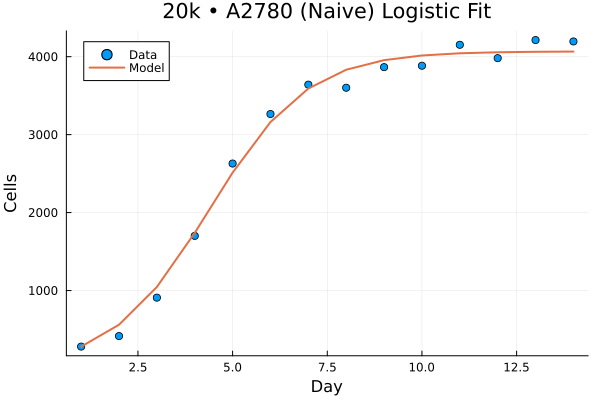

✓ Processed: A2780 (Naive) (20k) - r=0.770405, K=4068.59


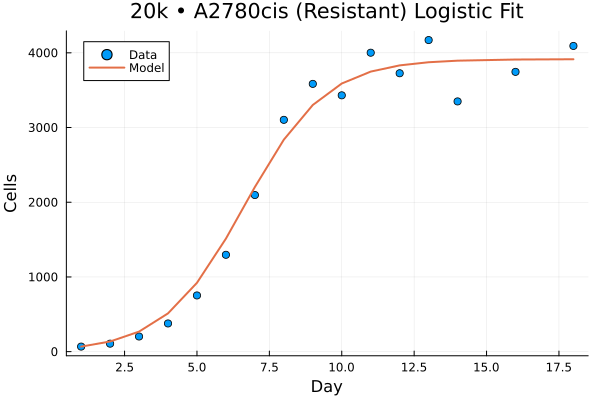

✓ Processed: A2780cis (Resistant) (20k) - r=0.71548, K=3914.9


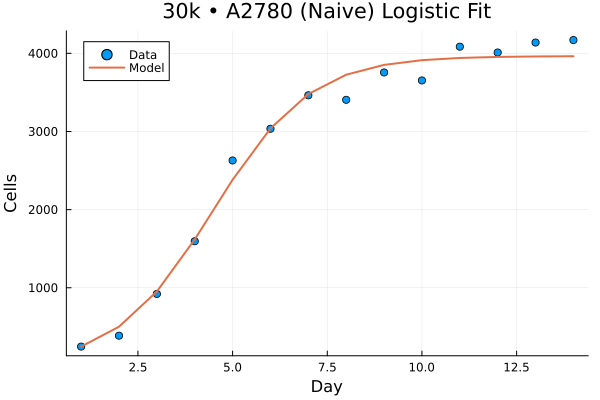

✓ Processed: A2780 (Naive) (30k) - r=0.780237, K=3965.09



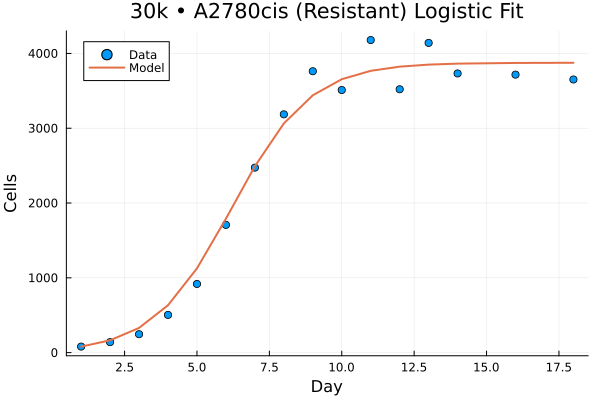

✓ Processed: A2780cis (Resistant) (30k) - r=0.740368, K=3875.43

Detailed Results:
4×7 DataFrame
 Row │ File                         Density  CellLine    r         K        SSR             BIC     
     │ String                       String   String      Float64   Float64  Float64         Float64 
─────┼──────────────────────────────────────────────────────────────────────────────────────────────
   1 │ A2780Naive_day_averages.csv  20k      A2780Naive  0.770405  4068.59       2.0407e5   139.498
   2 │ A2780cis_day_averages.csv    20k      A2780cis    0.71548   3914.9        8.04851e5  178.758
   3 │ A2780Naive_day_averages.csv  30k      A2780Naive  0.780237  3965.09       3.54807e5  147.242
   4 │ A2780cis_day_averages.csv    30k      A2780cis    0.740368  3875.43  650310.0        175.347


✓ Results exported to: c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Modelling Data Notebooks\Untreated MonoCulture\untreated_monoculture_logistic_parameters.csv

COMPREHENSIVE SUMMARY OF r A

In [17]:
# 8) Batch run for Untreated MonoCulture day averages only (20k and 30k) with error bars + per-file p# This cell processes ALL 4 datasets: A2780Naive and A2780cis for both 20k and 30k thresholds
# Navigate to project root (go up 2 levels from notebook directory)
project_root = dirname(dirname(pwd()))
roots = [
    joinpath(project_root, "Processed_Datasets", "Untreated MonoCulture", "20k", "Averages"),
    joinpath(project_root, "Processed_Datasets", "Untreated MonoCulture", "30k", "Averages"),
]

# Expected files for verification
expected_files = [
    "A2780Naive_day_averages.csv",
    "A2780cis_day_averages.csv"
]

files = String[]
for r in roots
    if isdir(r)
        println("Checking directory: $r")
        for expected_file in expected_files
            full_path = joinpath(r, expected_file)
            if isfile(full_path)
                push!(files, full_path)
                println("  ✓ Found: $expected_file")
            else
                @warn "  ✗ Missing: $expected_file"
            end
        end
    else
        @warn "Directory not found: $r"
    end
end

if isempty(files)
    @warn "No day averages CSVs found under Untreated MonoCulture"
else
    println("\nProcessing $(length(files)) day-average files...")
end

results = DataFrame(File=String[], Density=String[], CellLine=String[], r=Float64[], K=Float64[], SSR=Float64[], BIC=Float64[])
for f in files
    try
        x, y, yerr = load_day_averages(f)
        _, sol, fr = fit_logistic(x, y)
        den = infer_density(f)
        
        # Extract cell line from filename
        filename = basename(f)
        cell_line = split(filename, "_")[1]  # e.g., "A2780Naive" or "A2780cis"
        
        push!(results, (filename, den, cell_line, fr.r, fr.K, fr.SSR, fr.BIC))
        
        # Show per-file plot with error bars and density in title
        cell_type = cell_line == "A2780Naive" ? "A2780 (Naive)" : "A2780cis (Resistant)"
        title_str = "$den • $cell_type Logistic Fit"
        plot_data_and_fit(x, y, sol; title_str=title_str, yerr=yerr)
        
        println("✓ Processed: $cell_type ($den) - r=$(round(fr.r, digits=6)), K=$(round(fr.K, digits=2))")
    catch e
        @warn "Failed on $(basename(f)): $e"
    end
end

# Display results
println("\nDetailed Results:")
println(results)

# Export results to CSV
output_dir = pwd()  # Directory where the notebook is located
output_file = joinpath(output_dir, "untreated_monoculture_logistic_parameters.csv")
CSV.write(output_file, results)
println("\n✓ Results exported to: ", output_file)

# Print comprehensive summary for all 4 datasets
println("\n" * "="^60)
println("COMPREHENSIVE SUMMARY OF r AND K VALUES")
println("="^60)
println("All 4 datasets (both cell lines × both thresholds):")
println()

for density in ["20k", "30k"]
    println("$density Threshold:")
    println("-" ^ 20)
    for cell_line in ["A2780Naive", "A2780cis"]
        row = filter(r -> r.Density == density && r.CellLine == cell_line, results)
        if nrow(row) > 0
            r_val = row[1, :r]
            k_val = row[1, :K]
            cell_type = cell_line == "A2780Naive" ? "A2780 (Naive)" : "A2780cis (Resistant)"
            @printf("  %s: r = %.6f day⁻¹, K = %.2f cells\n", cell_type, r_val, k_val)
        else
            cell_type = cell_line == "A2780Naive" ? "A2780 (Naive)" : "A2780cis (Resistant)"
            println("  $cell_type: Data not found")
        end
    end
    println()
end

# Verify we processed all 4 expected datasets
expected_count = 4  # 2 cell lines × 2 thresholds
actual_count = nrow(results)
if actual_count == expected_count
    println("✓ Successfully processed all $actual_count expected datasets!")
else
    @warn "Expected $expected_count datasets but processed $actual_count"
end